# Regresión con procesos gaussianos

## 1. Introducción y objetivo

Este notebook estudia cómo la escala de longitud del kernel RBF controla la suavidad de una regresión con procesos gaussianos (GP). Se separan dos preguntas:

1. ¿Qué ocurre cuando se fijan realmente los valores $L=0.1$, $1.0$ y $10.0$?
2. ¿Qué escala y nivel de ruido selecciona el modelo al maximizar la log-verosimilitud marginal?

Como la función generadora es conocida, la media predictiva se evalúa mediante RMSE y MAE sobre una malla densa.

In [1]:
from pathlib import Path

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error

RNG_SEED = 12345
NOISE_STD = 0.1
TRAINING_X = np.array([0.5, 1.3, 1.4, 2.7, 3.5, 4.2, 5.8, 6.7], dtype=float)
FIXED_LENGTH_SCALES = (0.1, 1.0, 10.0)
X_GRID = np.linspace(0.0, 8.0, 400).reshape(-1, 1)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (PROJECT_ROOT / "notebooks" / "gaussian_process_regression.ipynb").exists():
    raise RuntimeError("Ejecuta el notebook desde la raíz del proyecto o desde notebooks/.")
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

## 2. Datos sintéticos

Las ocho observaciones se generan a partir de una función conocida y contienen ruido gaussiano independiente con desviación estándar $\sigma=0.1$ y una semilla fija.

In [2]:
def target_function(x):
    """Función generadora conocida."""
    x = np.asarray(x)
    return x * (10.0 - x) + np.sin(2.0 * np.pi * x)


rng = np.random.default_rng(RNG_SEED)
X_TRAIN = TRAINING_X.reshape(-1, 1)
Y_TRUE_TRAIN = target_function(TRAINING_X)
Y_TRAIN = Y_TRUE_TRAIN + rng.normal(0.0, NOISE_STD, size=TRAINING_X.size)
Y_TRUE_GRID = target_function(X_GRID.ravel())

print(f"Observaciones: {X_TRAIN.shape[0]}")
print(f"Rango objetivo observado: [{Y_TRAIN.min():.3f}, {Y_TRAIN.max():.3f}]")
print(f"Desviación estándar del ruido generador: {NOISE_STD:.3f}")

Observaciones: 8
Rango objetivo observado: [4.608, 25.237]
Desviación estándar del ruido generador: 0.100


## 3. Gaussian Process y kernel RBF

Un GP define una distribución sobre funciones. Aquí se usa

$$k(x,x') = A\exp\left[-\frac{(x-x')^2}{2L^2}\right] + \sigma_n^2\,\delta_{x,x'}.$$

La amplitud $A$ controla la variación vertical, $L$ determina qué tan rápido decae la correlación con la distancia y $\sigma_n^2$ representa ruido de observación. Un $L$ pequeño permite cambios locales; uno grande impone correlaciones más amplias y una media más suave.

Se usa normalize_y=True porque los objetivos tienen media claramente distinta de cero. Scikit-learn centra y escala los objetivos durante el ajuste y revierte la transformación al predecir. Por consistencia, el ruido inicial se convierte a unidades de varianza del objetivo normalizado.

In [3]:
def build_model(length_scale, optimize_length_scale):
    """Construye el mismo kernel, fijando u optimizando solo L según el experimento."""
    length_bounds = (1e-2, 1e2) if optimize_length_scale else "fixed"
    normalized_noise_variance = (NOISE_STD / Y_TRAIN.std()) ** 2
    kernel = (
        ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3))
        * RBF(length_scale=length_scale, length_scale_bounds=length_bounds)
        + WhiteKernel(
            noise_level=normalized_noise_variance,
            noise_level_bounds=(1e-8, 1e1),
        )
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=8,
        random_state=RNG_SEED,
    )


def fit_and_evaluate(length_scale, optimize_length_scale):
    model = build_model(length_scale, optimize_length_scale)
    model.fit(X_TRAIN, Y_TRAIN)
    mean, std = model.predict(X_GRID, return_std=True)
    return {
        "model": model,
        "mean": mean,
        "std": std,
        "rmse": mean_squared_error(Y_TRUE_GRID, mean) ** 0.5,
        "mae": mean_absolute_error(Y_TRUE_GRID, mean),
        "lml": model.log_marginal_likelihood_value_,
    }


def display_metrics(rows):
    lines = [
        "| Modelo | RMSE | MAE | Log-verosimilitud marginal |",
        "|---|---:|---:|---:|",
    ]
    lines.extend(
        f"| {name} | {result['rmse']:.4f} | {result['mae']:.4f} | {result['lml']:.4f} |"
        for name, result in rows
    )
    display(Markdown("\n".join(lines)))

## 4. Experimento 1: escalas de longitud fijas

En los tres modelos, `length_scale_bounds="fixed"`; por tanto, $L$ no cambia durante el ajuste. La amplitud y el nivel de ruido sí se optimizan mediante la log-verosimilitud marginal. Así se aísla el efecto de $L$ sin imponer valores arbitrarios a los otros parámetros.

## 5. Evaluación cuantitativa

RMSE y MAE comparan la media predictiva con la función generadora en los 400 puntos de la malla. La log-verosimilitud marginal (log-ML) evalúa las observaciones de entrenamiento bajo cada configuración.

In [4]:
fixed_results = {
    length_scale: fit_and_evaluate(length_scale, optimize_length_scale=False)
    for length_scale in FIXED_LENGTH_SCALES
}

display_metrics([
    (f"L fijo = {length_scale:g}", fixed_results[length_scale])
    for length_scale in FIXED_LENGTH_SCALES
])
print("\nKernels ajustados (L permanece fijo):")
for length_scale, result in fixed_results.items():
    print(f"L={length_scale:g}: {result['model'].kernel_}")

| Modelo | RMSE | MAE | Log-verosimilitud marginal |
|---|---:|---:|---:|
| L fijo = 0.1 | 5.6525 | 4.3683 | -10.8907 |
| L fijo = 1 | 1.1321 | 0.8916 | -6.8973 |
| L fijo = 10 | 0.8589 | 0.7068 | -6.7136 |


Kernels ajustados (L permanece fijo):
L=0.1: 0.971**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=1.57e-08)
L=1: 0.957**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.00594)
L=10: 12.6**2 * RBF(length_scale=10) + WhiteKernel(noise_level=0.0169)


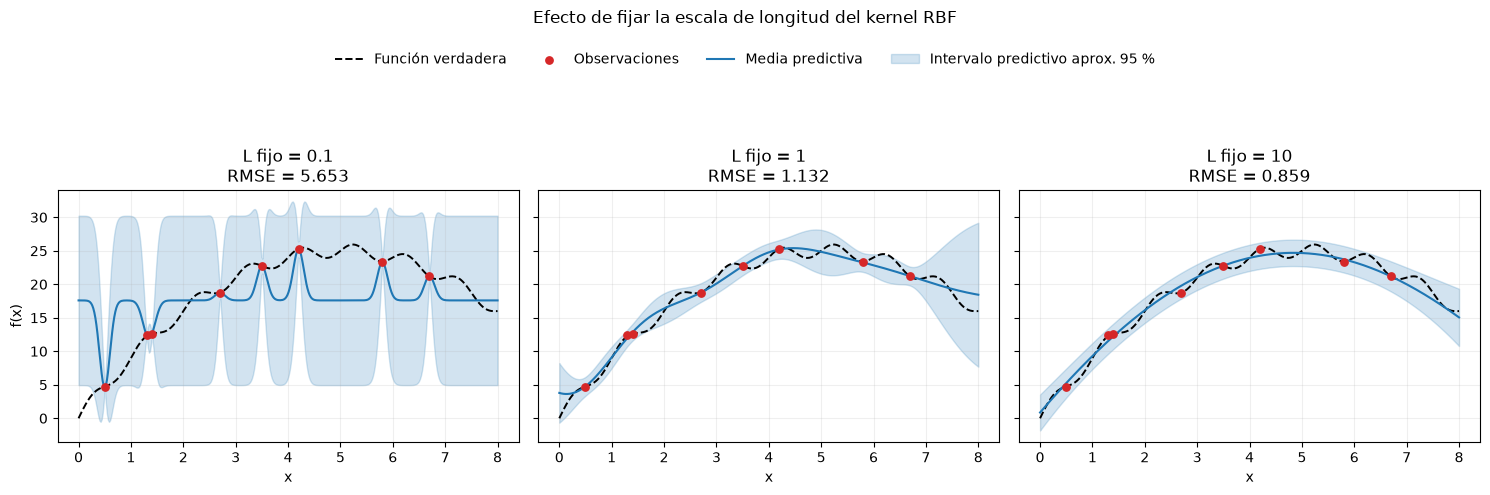

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.0), sharex=True, sharey=True)
for ax, length_scale in zip(axes, FIXED_LENGTH_SCALES):
    result = fixed_results[length_scale]
    mean, std = result["mean"], result["std"]
    ax.plot(X_GRID.ravel(), Y_TRUE_GRID, "k--", linewidth=1.4, label="Función verdadera")
    ax.scatter(TRAINING_X, Y_TRAIN, color="tab:red", s=28, zorder=3, label="Observaciones")
    ax.plot(X_GRID.ravel(), mean, color="tab:blue", label="Media predictiva")
    ax.fill_between(
        X_GRID.ravel(), mean - 1.96 * std, mean + 1.96 * std,
        color="tab:blue", alpha=0.2, label="Intervalo predictivo aprox. 95 %",
    )
    ax.set_title(f"L fijo = {length_scale:g}\nRMSE = {result['rmse']:.3f}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("f(x)")
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle("Efecto de fijar la escala de longitud del kernel RBF", y=0.98)
fig.legend(
    handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.92),
    ncol=4, frameon=False,
)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.80))
fig.savefig(FIGURE_DIR / "fixed_length_scales.png", dpi=180, bbox_inches="tight")
plt.show()

Las métricas y las curvas permiten interpretar cada escala sin asumir de antemano cuál debe ser mejor. La log-verosimilitud marginal evalúa los datos observados bajo cada configuración, mientras RMSE y MAE aprovechan la función verdadera conocida; por ello responden preguntas relacionadas, pero no idénticas.

## 6. Experimento 2: hiperparámetros optimizados

Ahora se ajusta un único modelo con el mismo kernel. Amplitud, length_scale y nivel de ruido pueden variar dentro de límites amplios. Scikit-learn selecciona estos valores maximizando la log-verosimilitud marginal, con reinicios reproducibles del optimizador.

In [6]:
optimized_result = fit_and_evaluate(length_scale=1.0, optimize_length_scale=True)
optimized_model = optimized_result["model"]
learned_length_scale = float(optimized_model.kernel_.k1.k2.length_scale)
learned_noise_level = float(optimized_model.kernel_.k2.noise_level)
learned_noise_std_original = np.sqrt(learned_noise_level) * Y_TRAIN.std()

print(f"Kernel aprendido: {optimized_model.kernel_}")
print(f"Length scale aprendido: {learned_length_scale:.6f}")
print(f"Nivel de ruido aprendido (varianza normalizada): {learned_noise_level:.8f}")
print(f"Desviación de ruido equivalente en unidades originales: {learned_noise_std_original:.6f}")
print(f"RMSE: {optimized_result['rmse']:.6f}")
print(f"MAE: {optimized_result['mae']:.6f}")
print(f"Log-verosimilitud marginal: {optimized_result['lml']:.6f}")

Kernel aprendido: 2.58**2 * RBF(length_scale=4.18) + WhiteKernel(noise_level=0.0238)
Length scale aprendido: 4.177650
Nivel de ruido aprendido (varianza normalizada): 0.02379733
Desviación de ruido equivalente en unidades originales: 1.024616
RMSE: 0.923420
MAE: 0.784008
Log-verosimilitud marginal: -5.396906


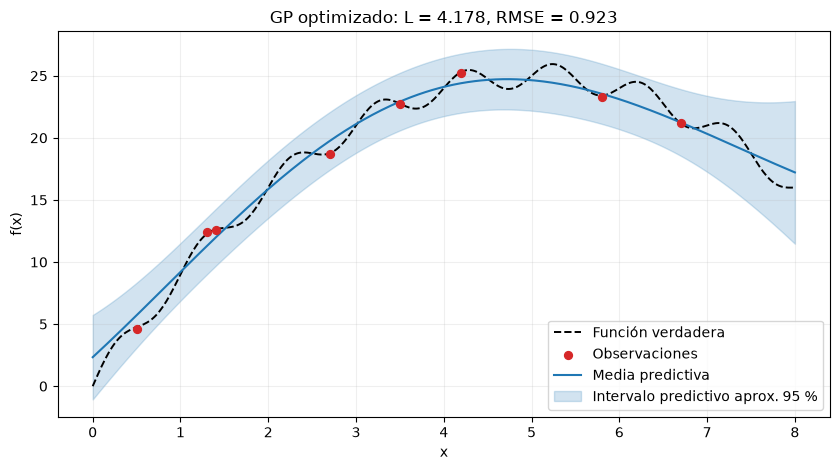

In [7]:
mean, std = optimized_result["mean"], optimized_result["std"]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(X_GRID.ravel(), Y_TRUE_GRID, "k--", linewidth=1.4, label="Función verdadera")
ax.scatter(TRAINING_X, Y_TRAIN, color="tab:red", s=32, zorder=3, label="Observaciones")
ax.plot(X_GRID.ravel(), mean, color="tab:blue", label="Media predictiva")
ax.fill_between(
    X_GRID.ravel(), mean - 1.96 * std, mean + 1.96 * std,
    color="tab:blue", alpha=0.2, label="Intervalo predictivo aprox. 95 %",
)
ax.set(
    xlabel="x", ylabel="f(x)",
    title=f"GP optimizado: L = {learned_length_scale:.3f}, RMSE = {optimized_result['rmse']:.3f}",
)
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "optimized_gp.png", dpi=180, bbox_inches="tight")
plt.show()

La banda muestra media $\pm 1.96$ desviaciones estándar predictivas. Como el kernel contiene `WhiteKernel`, esta desviación incluye el ruido de observación aprendido; no representa exclusivamente incertidumbre sobre la función latente. La banda es aproximada porque condiciona en los hiperparámetros ajustados y no incorpora incertidumbre sobre ellos.

## 7. Comparación de resultados

In [8]:
comparison_rows = [
    (f"L fijo = {length_scale:g}", fixed_results[length_scale])
    for length_scale in FIXED_LENGTH_SCALES
]
comparison_rows.append(("L optimizado", optimized_result))
display_metrics(comparison_rows)

| Modelo | RMSE | MAE | Log-verosimilitud marginal |
|---|---:|---:|---:|
| L fijo = 0.1 | 5.6525 | 4.3683 | -10.8907 |
| L fijo = 1 | 1.1321 | 0.8916 | -6.8973 |
| L fijo = 10 | 0.8589 | 0.7068 | -6.7136 |
| L optimizado | 0.9234 | 0.7840 | -5.3969 |

## 8. Conclusiones

- Fijar realmente $L$ produce modelos distintos. En esta malla, $L=10$ logra el menor RMSE (0.8589) y MAE (0.7068); $L=0.1$ es claramente peor porque su influencia queda muy localizada entre los pocos datos.
- El modelo optimizado aprende $L=4.1777$ y obtiene la mejor log-verosimilitud marginal (-5.3969), aunque su RMSE (0.9234) no supera al de $L=10$. El criterio de ajuste usa solo las observaciones y no conoce la función verdadera de la malla.
- La desviación de ruido aprendida equivale a 1.0246 en las unidades originales, frente a 0.1 del generador. Con ocho puntos, el GP suave puede atribuir al ruido parte de la oscilación no resuelta; este parámetro no debe interpretarse como una recuperación precisa del ruido real.
- El ejemplo muestra incertidumbre y selección de hiperparámetros dentro de ConstantKernel × RBF + WhiteKernel, pero no establece una regla universal sobre qué escala es mejor.